# Product Analysis

This section examines product categories, sales volume, and revenue contribution across the marketplace.

In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/raw")

products = pd.read_csv(
    DATA_DIR / "olist_products_dataset.csv"
)

product_category = pd.read_csv(
    DATA_DIR / "product_category_name_translation.csv"
)

In [2]:
products.shape

(32951, 9)

In [3]:
product_category.shape

(71, 2)

In [4]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [5]:
product_category.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [6]:
orders = pd.read_csv(
    DATA_DIR / "olist_orders_dataset.csv"
)

order_items = pd.read_csv(
    DATA_DIR / "olist_order_items_dataset.csv"
)

In [7]:
delivered_orders = orders.loc[
    orders["order_status"] == "delivered",
    "order_id"
]

delivered_items = order_items[
    order_items["order_id"].isin(delivered_orders)
].copy()

delivered_items.shape

(110197, 7)

In [8]:
delivered_items["product_id"].nunique()

32216

In [9]:
product_sales = delivered_items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

In [10]:
product_sales["product_category_name"].isna().sum()

np.int64(1537)

In [11]:
product_sales["product_category_name"].nunique()

73

In [12]:
product_sales["product_category_name"].value_counts().head(10)

product_category_name
cama_mesa_banho           10953
beleza_saude               9465
esporte_lazer              8431
moveis_decoracao           8160
informatica_acessorios     7644
utilidades_domesticas      6795
relogios_presentes         5859
telefonia                  4430
ferramentas_jardim         4268
automotivo                 4140
Name: count, dtype: int64

In [13]:
category_performance = (
    product_sales
    .dropna(subset=["product_category_name"])
    .groupby("product_category_name")
    .agg(
        items_sold=("order_id", "count"),
        orders=("order_id", "nunique"),
        revenue=("price", "sum"),
        avg_item_price=("price", "mean")
    )
    .reset_index()
)

In [14]:
category_performance = category_performance.sort_values(
    "revenue",
    ascending=False
).reset_index(drop=True)

category_performance.head(10)

,product_category_name,items_sold,orders,revenue,avg_item_price
0,beleza_saude,9465,8647,1233131.72,130.283330
1,relogios_presentes,5859,5495,1166176.98,199.040276
2,cama_mesa_banho,10953,9272,1023434.76,93.438762
3,esporte_lazer,8431,7530,954852.55,113.254958
4,informatica_acessorios,7644,6530,888724.61,116.264339
5,moveis_decoracao,8160,6307,711927.69,87.246040
6,utilidades_domesticas,6795,5743,615628.69,90.600249
7,cool_stuff,3718,3559,610204.10,164.121598
8,automotivo,4140,3810,578966.65,139.847017
9,brinquedos,4030,3804,471286.48,116.944536


In [15]:
category_performance[
    ["items_sold", "orders", "revenue", "avg_item_price"]
].describe()

,items_sold,orders,revenue,avg_item_price
count,73.000000,73.000000,7.300000e+01,73.000000
mean,1488.493151,1313.479452,1.787777e+05,146.550767
std,2529.680734,2204.673547,2.933088e+05,146.787079
min,2.000000,2.000000,2.832900e+02,25.342333
25%,73.000000,72.000000,7.528410e+03,77.523860
50%,269.000000,241.000000,4.530215e+04,116.264339
75%,1668.000000,1254.000000,1.843157e+05,154.407282
max,10953.000000,9272.000000,1.233132e+06,1098.915276


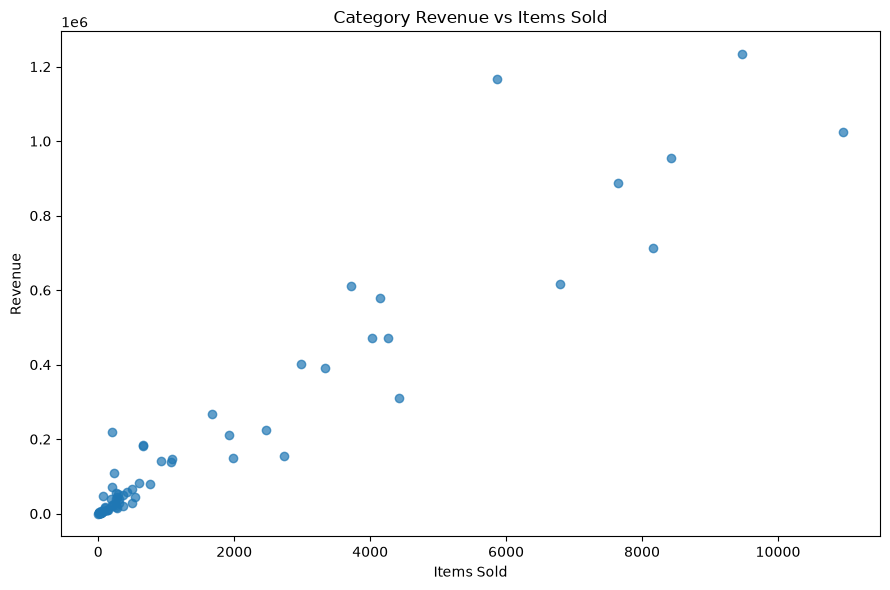

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    category_performance["items_sold"],
    category_performance["revenue"],
    alpha=0.7
)

plt.title("Category Revenue vs Items Sold")
plt.xlabel("Items Sold")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [17]:
category_performance[
    ["items_sold", "revenue"]
].corr()

,items_sold,revenue
items_sold,1.000000,0.951113
revenue,0.951113,1.000000


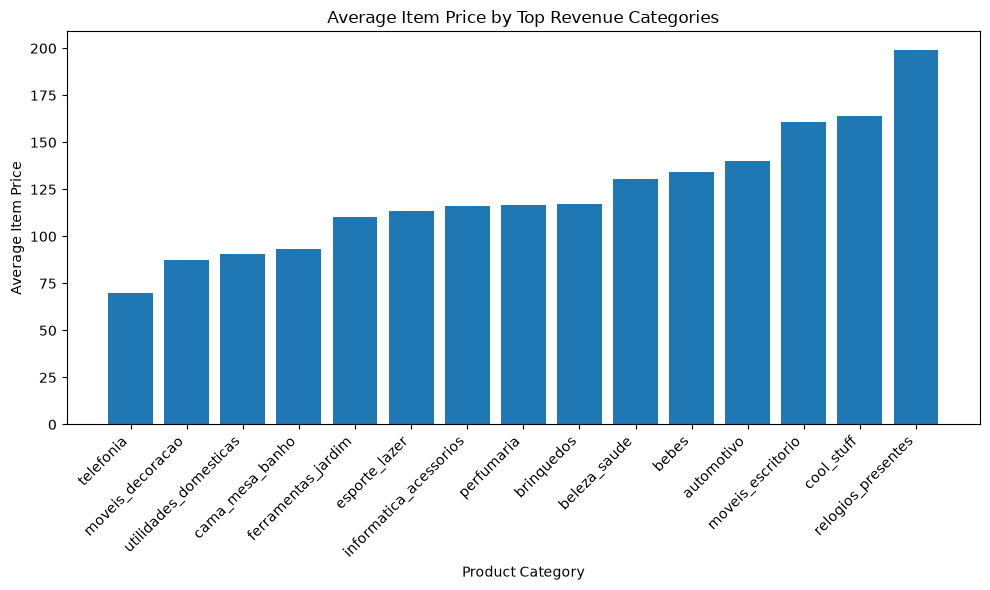

In [18]:
plt.figure(figsize=(10, 6))

top_categories = category_performance.head(15).sort_values(
    "avg_item_price"
)

plt.bar(
    top_categories["product_category_name"],
    top_categories["avg_item_price"]
)

plt.title("Average Item Price by Top Revenue Categories")
plt.xlabel("Product Category")
plt.ylabel("Average Item Price")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Key Finding

Category revenue is strongly associated with sales volume, with a correlation of 0.95 between items sold and revenue. However, average item prices vary substantially across categories, meaning that categories with similar sales volumes can generate different levels of revenue.

For example, `relogios_presentes` has a much higher average item price than high-volume categories such as `cama_mesa_banho`, helping explain its strong revenue contribution despite lower sales volume.